In [1]:
import numpy as np
import scipy.constants as sc
import matplotlib.pyplot as plt
from pygmid import Lookup as lk
from scipy.interpolate import interp1d
from scipy.interpolate import CubicSpline
pmos4 = lk('lookup_table/035/pmos4.mat')
nmos4 = lk('lookup_table/035/nmos4.mat')
# Interpolation function
def interp1(x, y, value):
    # Perform cubic interpolation using interp1d
    f = interp1d(x, y, kind='cubic')
    return f(value)
import adri as adri

In [2]:
#Specification
VDD = 2.7
gmID1 = 15
Lnmos = 0.5
I_in = 100e-6

# Simple current mirror
  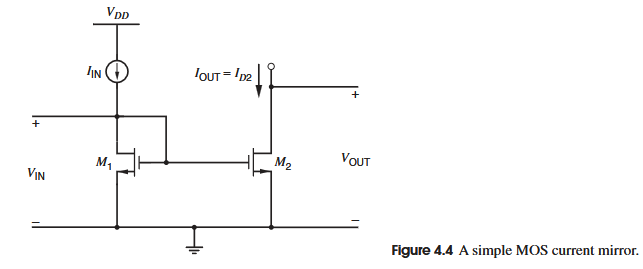

In [3]:
#Short version
    #Arg :  
        #spec. : input_current
        #param. : l_mos, gm_id1
    #return 
        #perf : Rout, vin_min, vout_min
        #MOS. : Name, W, L, VGS, VDS, gm_id
spec = {'input_current' : 100e-6}
param = {'l_mos' : 0.5, 'gm_id1' : 20}

mos, perf = adri.currentMirror(nmos4, spec, param)


In [4]:
# Accéder aux données stockées dans cm

# Méthode 1 : Déballer le tuple
mos, perf = mos, perf = adri.currentMirror(nmos4, spec, param)

# Afficher les performances
print("=== PERFORMANCES ===")
print(f"Rout = {perf['Rout']:.2e} Ohm")
print(f"Vin_min = {perf['vin_min']:.4f} V")
print(f"Vout_min = {perf['vout_min']:.4f} V")

# Afficher les données de MOS1
print("\n=== MOS1 ===")
mos1 = mos['MOS1']
print(f"Nom: {mos1['NAME']}")
print(f"W = {mos1['W']:.4f} um")
print(f"L = {mos1['L']:.4f} um")
print(f"VGS = {mos1['VGS']:.4f} V")
print(f"VDS = {mos1['VDS']:.4f} V")
print(f"GM/ID = {mos1['GM_ID']:.4f}")

# Afficher les données de MOS2
print("\n=== MOS2 ===")
mos2 = mos['MOS2']
print(f"Nom: {mos2['NAME']}")
print(f"W = {mos2['W']:.4f} um")
print(f"L = {mos2['L']:.4f} um")
print(f"VGS = {mos2['VGS']:.4f} V")
print(f"VDS = {mos2['VDS']:.4f} V")
print(f"GM/ID = {mos2['GM_ID']:.4f}")

# Boucler sur tous les transistors
print("\n=== BOUCLE SUR TOUS LES TRANSISTORS ===")
for mos_name, mos_data in mos.items():
    print(f"\n{mos_name}:")
    print(f"  W = {mos_data['W']:.4f} um")
    print(f"  L = {mos_data['L']:.4f} um")


=== PERFORMANCES ===
Rout = 7.41e+04 Ohm
Vin_min = 0.5817 V
Vout_min = 0.5773 V

=== MOS1 ===
Nom: MOS1
W = 173.7045 um
L = 0.5000 um
VGS = 0.5817 V
VDS = 0.5773 V
GM/ID = 20.0000

=== MOS2 ===
Nom: MOS2
W = 173.7045 um
L = 0.5000 um
VGS = 0.5817 V
VDS = 0.5773 V
GM/ID = 20.0000

=== BOUCLE SUR TOUS LES TRANSISTORS ===

MOS1:
  W = 173.7045 um
  L = 0.5000 um

MOS2:
  W = 173.7045 um
  L = 0.5000 um


VEA1 = 9.49 V


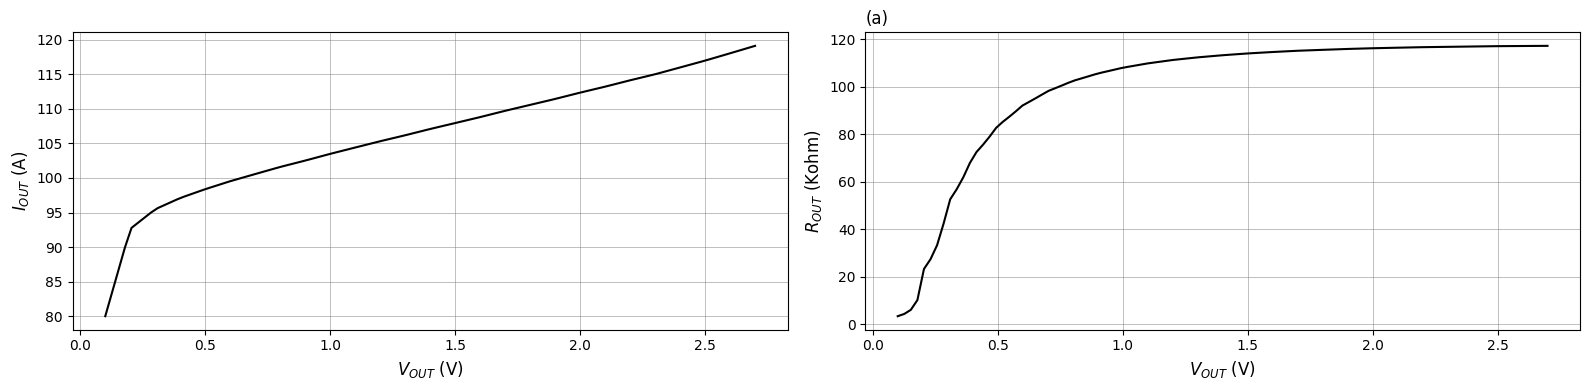

In [8]:
#Two Step evaluation of VGS, with 1er eval to get a 1st VDS value
VGS1 = nmos4.lookupVGS(GM_ID=gmID1, L=Lnmos)
VDS1 = VGS1
VGS1 = nmos4.lookupVGS(GM_ID=gmID1, VDS=VDS1, L=Lnmos)


JD1  = nmos4.lookup('ID_W', VGS=VGS1, VDS=VDS1, L=Lnmos)
W1 = I_in / JD1
#############################print('W1 = %.2F um' % (W1))
VOUT = np.linspace(0.1,VDD,100)
VDS2 = VOUT
ID2 = W1 * nmos4.look_up('ID_W',VGS=VGS1, VDS=VDS2, L=Lnmos)
Rout = 1 / (W1 * nmos4.look_up('GDS_W',VGS=VGS1, VDS=VDS2, L=Lnmos))

gds1 = nmos4.lookup('GDS_W', VGS=VGS1, VDS=VGS1, L=Lnmos)
VEA1 = JD1 / gds1
print('VEA1 = %.2F V' % (VEA1))

fig, (ax1, ax2) = plt.subplots(1,2,figsize=(16, 4))
ax1.plot(VOUT, ID2*1e6, color='black', linewidth=1.5)
ax1.set_xlabel('$V_{OUT}$ (V)', fontsize=12)
ax1.set_ylabel('$I_{OUT}$ (A)', fontsize=12)
ax1.grid(True, which='both', linestyle='-', linewidth=0.5, color='gray', alpha=0.7)
#ax.ticklabel_format(axis='y', style='sci', scilimits=(-4, -4), useMathText=True)
ax2.set_title('(a)', loc='left', fontsize=12, fontweight='normal')
ax2.plot(VOUT, Rout*1e-3, color='black', linewidth=1.5)
ax2.set_xlabel('$V_{OUT}$ (V)', fontsize=12)
ax2.set_ylabel('$R_{OUT}$ (Kohm)', fontsize=12)
ax2.grid(True, which='both', linestyle='-', linewidth=0.5, color='gray', alpha=0.7)
#ax.ticklabel_format(axis='y', style='sci', scilimits=(-4, -4), useMathText=True)
ax2.set_title('(a)', loc='left', fontsize=12, fontweight='normal')
plt.tight_layout()
plt.show()

# High Swing cascode current mirror
_obj : high output resistance and the smallest possible compliance voltage_  
  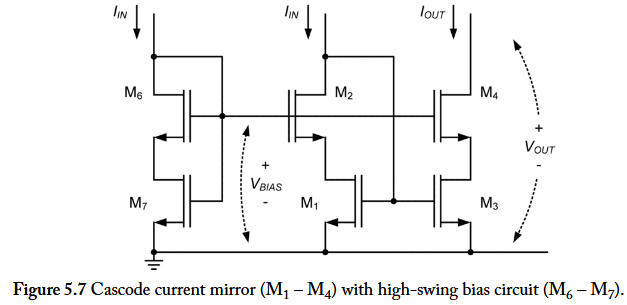 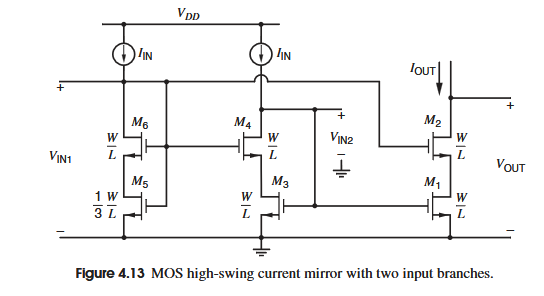

In [6]:
#Exemple using function
spec = {'input_current' : 100e-6}
param = {'l_mos' : 0.5, 'gm_id1' : 15}

mos, perf = adri.currentMirrorCascode(nmos4, spec, param)

perf




{'Rout': np.float64(3131495.267825321),
 'vin_min': np.float64(0.8967611219064564),
 'vout_min': np.float64(0.3316778177746238)}

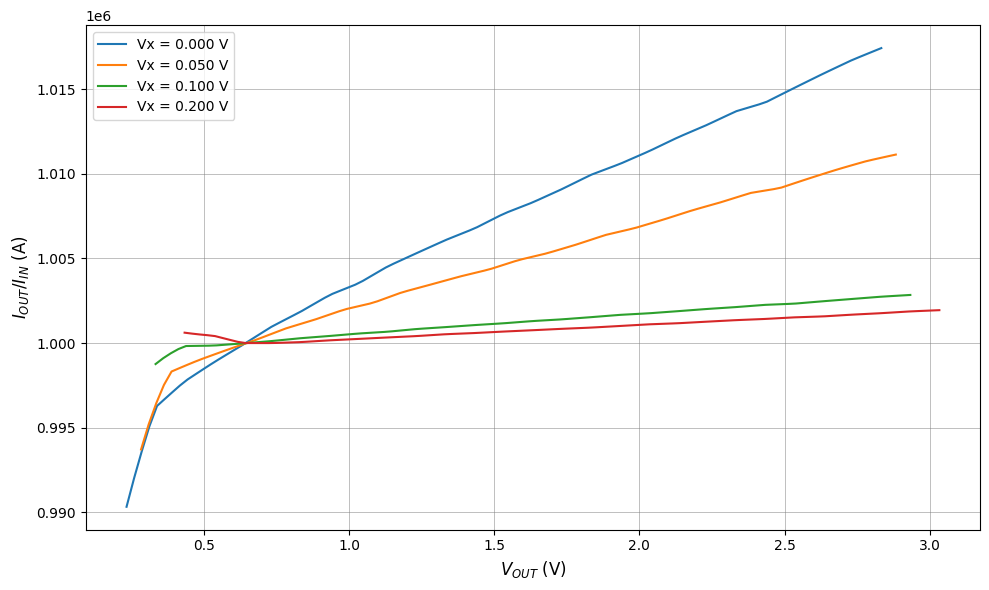

In [7]:
#Exemple a plat
Vx = np.array([0, 0.05, 0.1, 0.2])

S = np.linspace(0,400) * 0.001
VOUT = np.linspace(0.1,VDD,100)
Iout_results = []
VOUT_results = []
for k in range(len(Vx)):
    VDS1 = 2.0 / gmID1 + Vx[k]
    #print('VDS1 = %.2F V' % (VDS1))


    VGS1 = nmos4.lookupVGS(GM_ID=gmID1, VDS=VDS1, L=Lnmos,VSB=0)
    VEA1 = nmos4.look_up('ID_GDS', VGS=VGS1, VDS=VDS1, L=Lnmos,VSB=0)

    #print('VEA1 = %.2F V' % (VEA1))
    #print('VGS1 = %.2F V' % (VGS1))

    JD1 = nmos4.look_up('ID_W', VGS=VGS1, VDS=VDS1, L=Lnmos, VSB=0)
    JD2 = nmos4.look_up('ID_W', VGS=VGS1+S, VDS=VGS1-VDS1, L=Lnmos, VSB=-VDS1)
    #print(JD2/JD1)
    VGS2 = interp1(JD2/JD1, VGS1+S, 1)
    #print('VGS2 = %.2F V' % (VGS2))
    VBIAS = VDS1+VGS2
    #print('VBIAS = %.2F V' % (VBIAS))

    W = I_in / JD1
    #print('W = %.2F um' % (W))

    gm4_id = nmos4.look_up('GM_ID', VGS=VGS2, VDS=VGS1-VDS1, VSB=-VDS1, L=Lnmos)
    gmb4_id = nmos4.look_up('GMB_ID', VGS=VGS2, VDS=VGS1-VDS1, VSB=-VDS1, L=Lnmos)
    gds4_id = nmos4.look_up('GDS_ID', VGS=VGS2, VDS=VGS1-VDS1, VSB=-VDS1, L=Lnmos)

    A4 = (gm4_id+gmb4_id+gds4_id+1/VEA1) / gds4_id
    VEA_cascode = VEA1 * A4
    Rout = VEA_cascode / I_in
    #print('VEA_cascode = %.2F V' % (VEA_cascode))
    #print('Rout = %.2F Mohm' % (Rout*1e-6))

    #Bias circuit
    JD6 = nmos4.look_up('ID_W', VGS=VGS2, VDS=VGS2, VSB=-VDS1, L=Lnmos)
    ID6 = W * JD6
    #print('ID6 = %.2F uA' % (ID6*1e6))
    JD7 = nmos4.look_up('ID_W', VGS=VBIAS, VDS = VBIAS, L=Lnmos)
    W7 = I_in / JD7
    #print('W7 = %.2F um' % (W7))

    """     print('RECAP')
    print('Vx = %.2F V' % (Vx[k]))
    print('W_all = %.2F um' % (W))
    print('L_all = %.2F um' % (Lnmos))
    print('W7 = %.2F um' % (W7)) 
    """


    ##Output current
    VDS2  = np.linspace(0.1, 2.7, 100)
    VOUT = VDS2+VDS1
    x = np.linspace(-3,4) * 0.03
    zV = len(VDS2)
    zx = len(x)
    JD1 = nmos4.look_up('ID_W', VGS=VGS1, VDS=VDS1+x, L=Lnmos)
  
    Iout = np.zeros(zV)
    for j in range(zV):
        JD2 = np.diag(nmos4.look_up('ID_W', VGS=VGS2-x, VDS=VDS2[j], VSB=(-VDS1-x), L=Lnmos))
        Iout[j] = W * interp1(JD2/JD1, JD1,1) / I_in

    Iout_results.append(Iout)
    VOUT_results.append(VOUT)

# Plot all 3 curves together
fig, ax = plt.subplots(figsize=(10, 6))
for k in range(len(Vx)):
        
    ax.plot(VOUT_results[k], Iout_results[k]*1e6, linewidth=1.5, label=f'Vx = {Vx[k]:.3f} V')
ax.set_xlabel('$V_{OUT}$ (V)', fontsize=12)
ax.set_ylabel('$I_{OUT} / I_{IN}$ (A)', fontsize=12)
ax.grid(True, which='both', linestyle='-', linewidth=0.5, color='gray', alpha=0.7)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()